# Нейронные сети

В этой работе пригодится библиотека PyTorch из лабораторной работы №1.

По нейронным сетям в интернете можно найти огромное количество информации и примеров (официальная документация фреймворка, Kaggle, даже ChatGPT, хотя последний стоит использовать с осторожностью) - вы можете использовать любые материалы в текущей работе, но будьте готовы ответить на вопросы по коду во время защиты.

Вспомогательные материалы:

[Курс по нейронным сетям](https://stepik.org/course/110281/syllabus)

[ШАД-овский курс по глубокому обучению](https://github.com/yandexdataschool/Practical_DL/tree/fall23)


В целом, содержательно данная работа дублирует часть курса по Глубокому обучению.


## Основы нейронных сетей (4 балла)

Кратко обсудим основные концепции, понимание которых необходимо для работы с PyTorch. В других фреймворках для нейронных сетей всё очень похоже.

1. **Датасеты**
  
  В PyTorch датасеты представлены классами `torch.utils.data.Dataset` или его наследниками. Они позволяют загружать данные и предоставляют доступ к ним для обучения и валидации.

2. **Нейронные сети**

  *Слои*

  Нейронные сети в PyTorch строятся с использованием `torch.nn.Module` (не единственный, но самый распространенный способ). Слои определяются внутри этих модулей и могут быть полносвязными (`torch.nn.Linear`), сверточными (`torch.nn.Conv2d`), рекуррентными (`torch.nn.LSTM`, `torch.nn.GRU`) и другими. Сло имеют входную и выходную размерность. В нейронной сети выходная размерность слоя должна быть равна входной размерности последующего слоя.

  *Функции активации*

  Функции активации, такие как ReLU (`torch.nn.ReLU`), Sigmoid (`torch.nn.Sigmoid`), Tanh (`torch.nn.Tanh`) и другие, применяются к выходу слоя для добавления нелинейности в сеть.

  *Лосс-функции*

  Лосс-функции измеряют расхождение между прогнозами модели и фактическими значениями. В зависимости от типа задачи могут использоваться различные функции активации, например, `torch.nn.CrossEntropyLoss` для классификации и `torch.nn.MSELoss` для регрессии.

  *Оптимизаторы*

  Оптимизаторы в PyTorch, такие как `torch.optim.SGD`, `torch.optim.Adam`, `torch.optim.Adagrad` и другие, используются для обновления параметров сети в процессе обучения с целью минимизации функции потерь.

  *Планировщики (шедулеры)*

  Планировщики позволяют динамически изменять скорость обучения в процессе обучения. Например, `torch.optim.lr_scheduler.ReduceLROnPlateau` уменьшает скорость обучения, если ошибка перестает уменьшаться, а `torch.optim.lr_scheduler.StepLR` или `torch.optim.lr_scheduler.CosineAnnealingLR` изменяют скорость обучения в заданные моменты или с периодическим расписанием.

3. **Обучение и валидация**

  Обучение модели включает в себя передачу данных через сеть, вычисление функции потерь, вычисление градиентов, обновление весов с использованием оптимизатора и повторение этого процесса на протяжении нескольких эпох. После обучения модели необходимо провести валидацию на независимом наборе данных для оценки ее производительности.

[Визуализация работы нейронных сетей](https://playground.tensorflow.org/).

Потренируемся писать полный цикл обучения нейронной сети на [следующем наборе данных](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data).

P.S. предлагаемая архитектура сети не является оптимальной, но позволяет научиться работать с основными строительными блоками PyTorch-а.

Прочитайте датасет (можно использовать библиотеку `opendatasets` для выгрузки данных с Kaggle). Посчитайте основные числовые характеристики для каждого столбца. Проанализируйте датасет на предмет дисбаланса классов. Сделайте вывод о необходимости каких-либо преобразований над данными.

Разбейте выборку на тренировочную и тестовую (`test_size=0.2, random_state=42`), проведите необходимые преобразования.

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt

# Скачиваем датасет Breast Cancer с Kaggle
od.download("https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data")

df = pd.read_csv('breast-cancer-wisconsin-data/data.csv')

print("=== Размер датасета ===")
print(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")

print("\n=== Первые строки ===")
print(df.head())

print("\n=== Информация о столбцах ===")
print(df.info())

print("\n=== Базовые числовые характеристики ===")
print(df.describe())

print("\n=== Анализ дисбаланса классов ===")
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True).round(3))
# Вывод: классы относительно сбалансированы (M ~37%, B ~63%),
# нормализация признаков необходима, т.к. у них разный масштаб.

print("\n=== Пропуски ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Преобразуем таргет: M (злокачественная) -> 1, B (доброкачественная) -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Удаляем нерелевантные столбцы
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Разбиваем на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Нормализация: StandardScaler приводит признаки к нулевому среднему
# и единичной дисперсии — необходима, т.к. нейросеть чувствительна к масштабу
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Собираем DataFrame-ы с таргетом для передачи в Dataset
train_df = pd.DataFrame(X_train_sc, columns=X.columns)
train_df['diagnosis'] = y_train.values
test_df = pd.DataFrame(X_test_sc, columns=X.columns)
test_df['diagnosis'] = y_test.values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nИспользуется устройство: {device}")
print(f"Train: {train_df.shape}, Test: {test_df.shape}")


Создайте класс датасета. Типы данных, которые вам потребуются: `dtype=torch.float32`, `dtype=torch.long`.

Инициализируйте даталоадеры (`batch_size=32`) для тренировочных и тестовых данных. Для теста данные перемешивать (параметр `shuffle`) не надо!

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, dataframe):
        # Все столбцы кроме таргета — признаки
        self.data = torch.tensor(
            dataframe.drop(columns=['diagnosis']).values,
            dtype=torch.float32
        )
        # Таргет — целочисленные метки классов (требование CrossEntropyLoss)
        self.target = torch.tensor(
            dataframe['diagnosis'].values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.target[idx]


train_dataset = CustomDataset(train_df)
test_dataset  = CustomDataset(test_df)

# shuffle=True для train — перемешиваем батчи на каждой эпохе
# shuffle=False для test — порядок не важен, но воспроизводимость нужна
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Батчей в train_loader: {len(train_loader)}")
print(f"Батчей в test_loader:  {len(test_loader)}")


Создайте полносвязную нейронную сеть из нескольких слоёв. Между слоями используйте ReLU.

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        # Три полносвязных слоя с убывающей шириной
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)   # 2 класса: benign и malignant
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)   # логиты — CrossEntropyLoss применяет softmax внутри
        return x


Следующий небольшой кусочек кода написан за вас. В нём используется кросс-энтропия в качестве функции потерь. Вспомните, какими характеристиками обладает данная функция и в чём особенность её реализации в PyTorch.

Письменно ответьте на вопрос, как сигмоидальная функция потерь соотносится с кросс-энтропийной.

In [ ]:
model = NeuralNetwork(input_size=train_df.shape[1] - 1).to(device)  # -1 за счет таргета
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 15
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

**Ваш ответ:**

Сигмоидальная функция и кросс-энтропия тесно связаны: при бинарной классификации сигмоида применяется к выходу модели, чтобы получить вероятность, после чего вычисляется **бинарная кросс-энтропия** (BCE). Формула BCE фактически является частным случаем общей кросс-энтропии для двух классов.

В PyTorch `nn.CrossEntropyLoss` объединяет в себе `LogSoftmax + NLLLoss` и принимает **сырые логиты** (без предварительного применения softmax или сигмоиды). Это сделано намеренно: совместное вычисление численно устойчивее, чем последовательное применение softmax и затем взятие логарифма.

При двух классах `nn.CrossEntropyLoss(logits)` даёт результат, эквивалентный `nn.BCEWithLogitsLoss(logits[:, 1])`, — оба варианта вычисляют одно и то же, просто `CrossEntropyLoss` работает с векторами логитов для любого числа классов.


Напишите функции для тренировки и тестирования модели. Не забудьте про `optimizer.zero_grad()` при тренировке и `with torch.no_grad()` в тесте.

Также обратите внимание, что шаг планировщика нужно совершать после шага оптимизатора.

In [ ]:
def train(model, train_loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss   = 0.0
    correct_train  = 0
    total_train    = 0

    for inputs, labels in tqdm(train_loader):
        # Перемещение данных на устройство (GPU или CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        # Обнуление градиентов параметров модели
        optimizer.zero_grad()
        # Прямой проход: получение прогнозов от модели
        outputs = model(inputs)
        # Вычисление значения функции потерь
        loss = criterion(outputs, labels)
        # Обратное распространение: вычисление градиентов
        loss.backward()
        # Обновление параметров модели с помощью оптимизатора
        optimizer.step()
        # Вычисление точности модели (Accuracy)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train   += labels.size(0)
        # Аккумулирование потерь по батчам (взвешенно по размеру батча)
        running_loss  += loss.item() * inputs.size(0)

    # Вычисление средней потери и точности на тренировочном наборе данных
    train_loss     = running_loss / total_train
    train_accuracy = correct_train / total_train
    # Обновление шага расписания (scheduler) — после шага оптимизатора
    scheduler.step()

    return train_loss, train_accuracy


def test(model, test_loader, criterion, device):
    model.eval()
    running_loss  = 0.0
    correct_test  = 0
    total_test    = 0

    with torch.no_grad():
        # Проход по данным тестового загрузчика
        for inputs, labels in tqdm(test_loader):
            # Перемещение данных на устройство (GPU или CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            # Получение прогнозов от модели
            outputs = model(inputs)
            # Вычисление значения функции потерь
            loss = criterion(outputs, labels)
            # Вычисление точности модели (Accuracy)
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test   += labels.size(0)
            # Аккумулирование потерь по батчам
            running_loss += loss.item() * inputs.size(0)

    # Вычисление средней потери и точности на тестовом наборе данных
    test_loss     = running_loss / total_test
    test_accuracy = correct_test / total_test

    return test_loss, test_accuracy


Создайте цикл обучения вашей нейронной сети, используя написанные ранее функции.

Печатайте прогресс на каждой эпохе (`train_loss, train_accuracy, test_loss, test_accuracy`).

Постройте графики лосса и точности. Должно получиться что-то такое:

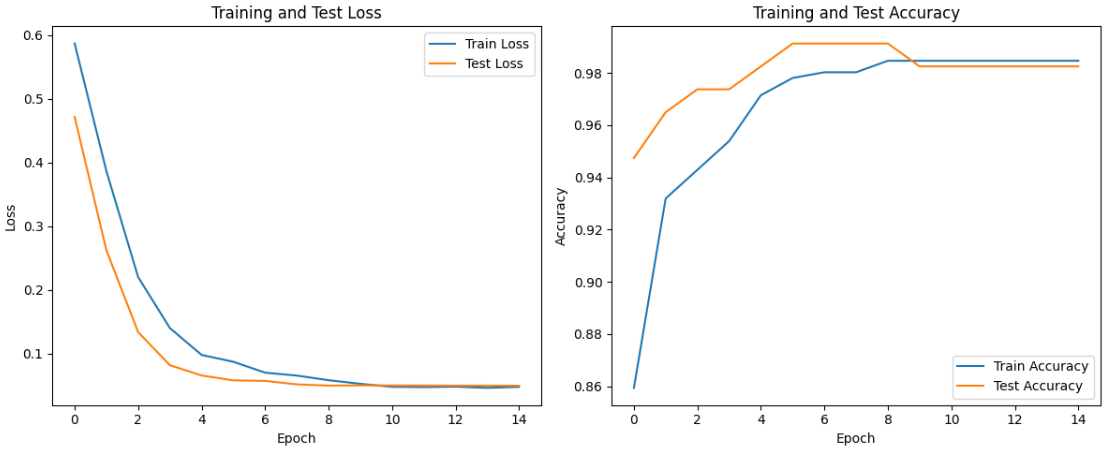

In [ ]:
# Цикл обучения: num_epochs эпох
for epoch in range(num_epochs):
    train_loss, train_accuracy = train(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    test_loss, test_accuracy = test(
        model, test_loader, criterion, device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
        f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_accuracy:.4f}"
    )

# Графики лосса и точности
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs + 1), test_losses,  label='Test Loss')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Функция потерь')
ax1.legend()

ax2.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
ax2.plot(range(1, num_epochs + 1), test_accuracies,  label='Test Accuracy')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.set_title('Точность')
ax2.legend()

plt.tight_layout()
plt.show()

# torch.save(model.state_dict(), 'model_checkpoint.pth') - можно сохранить модель по итогу обучения


## Специальные архитектуры нейронных сетей

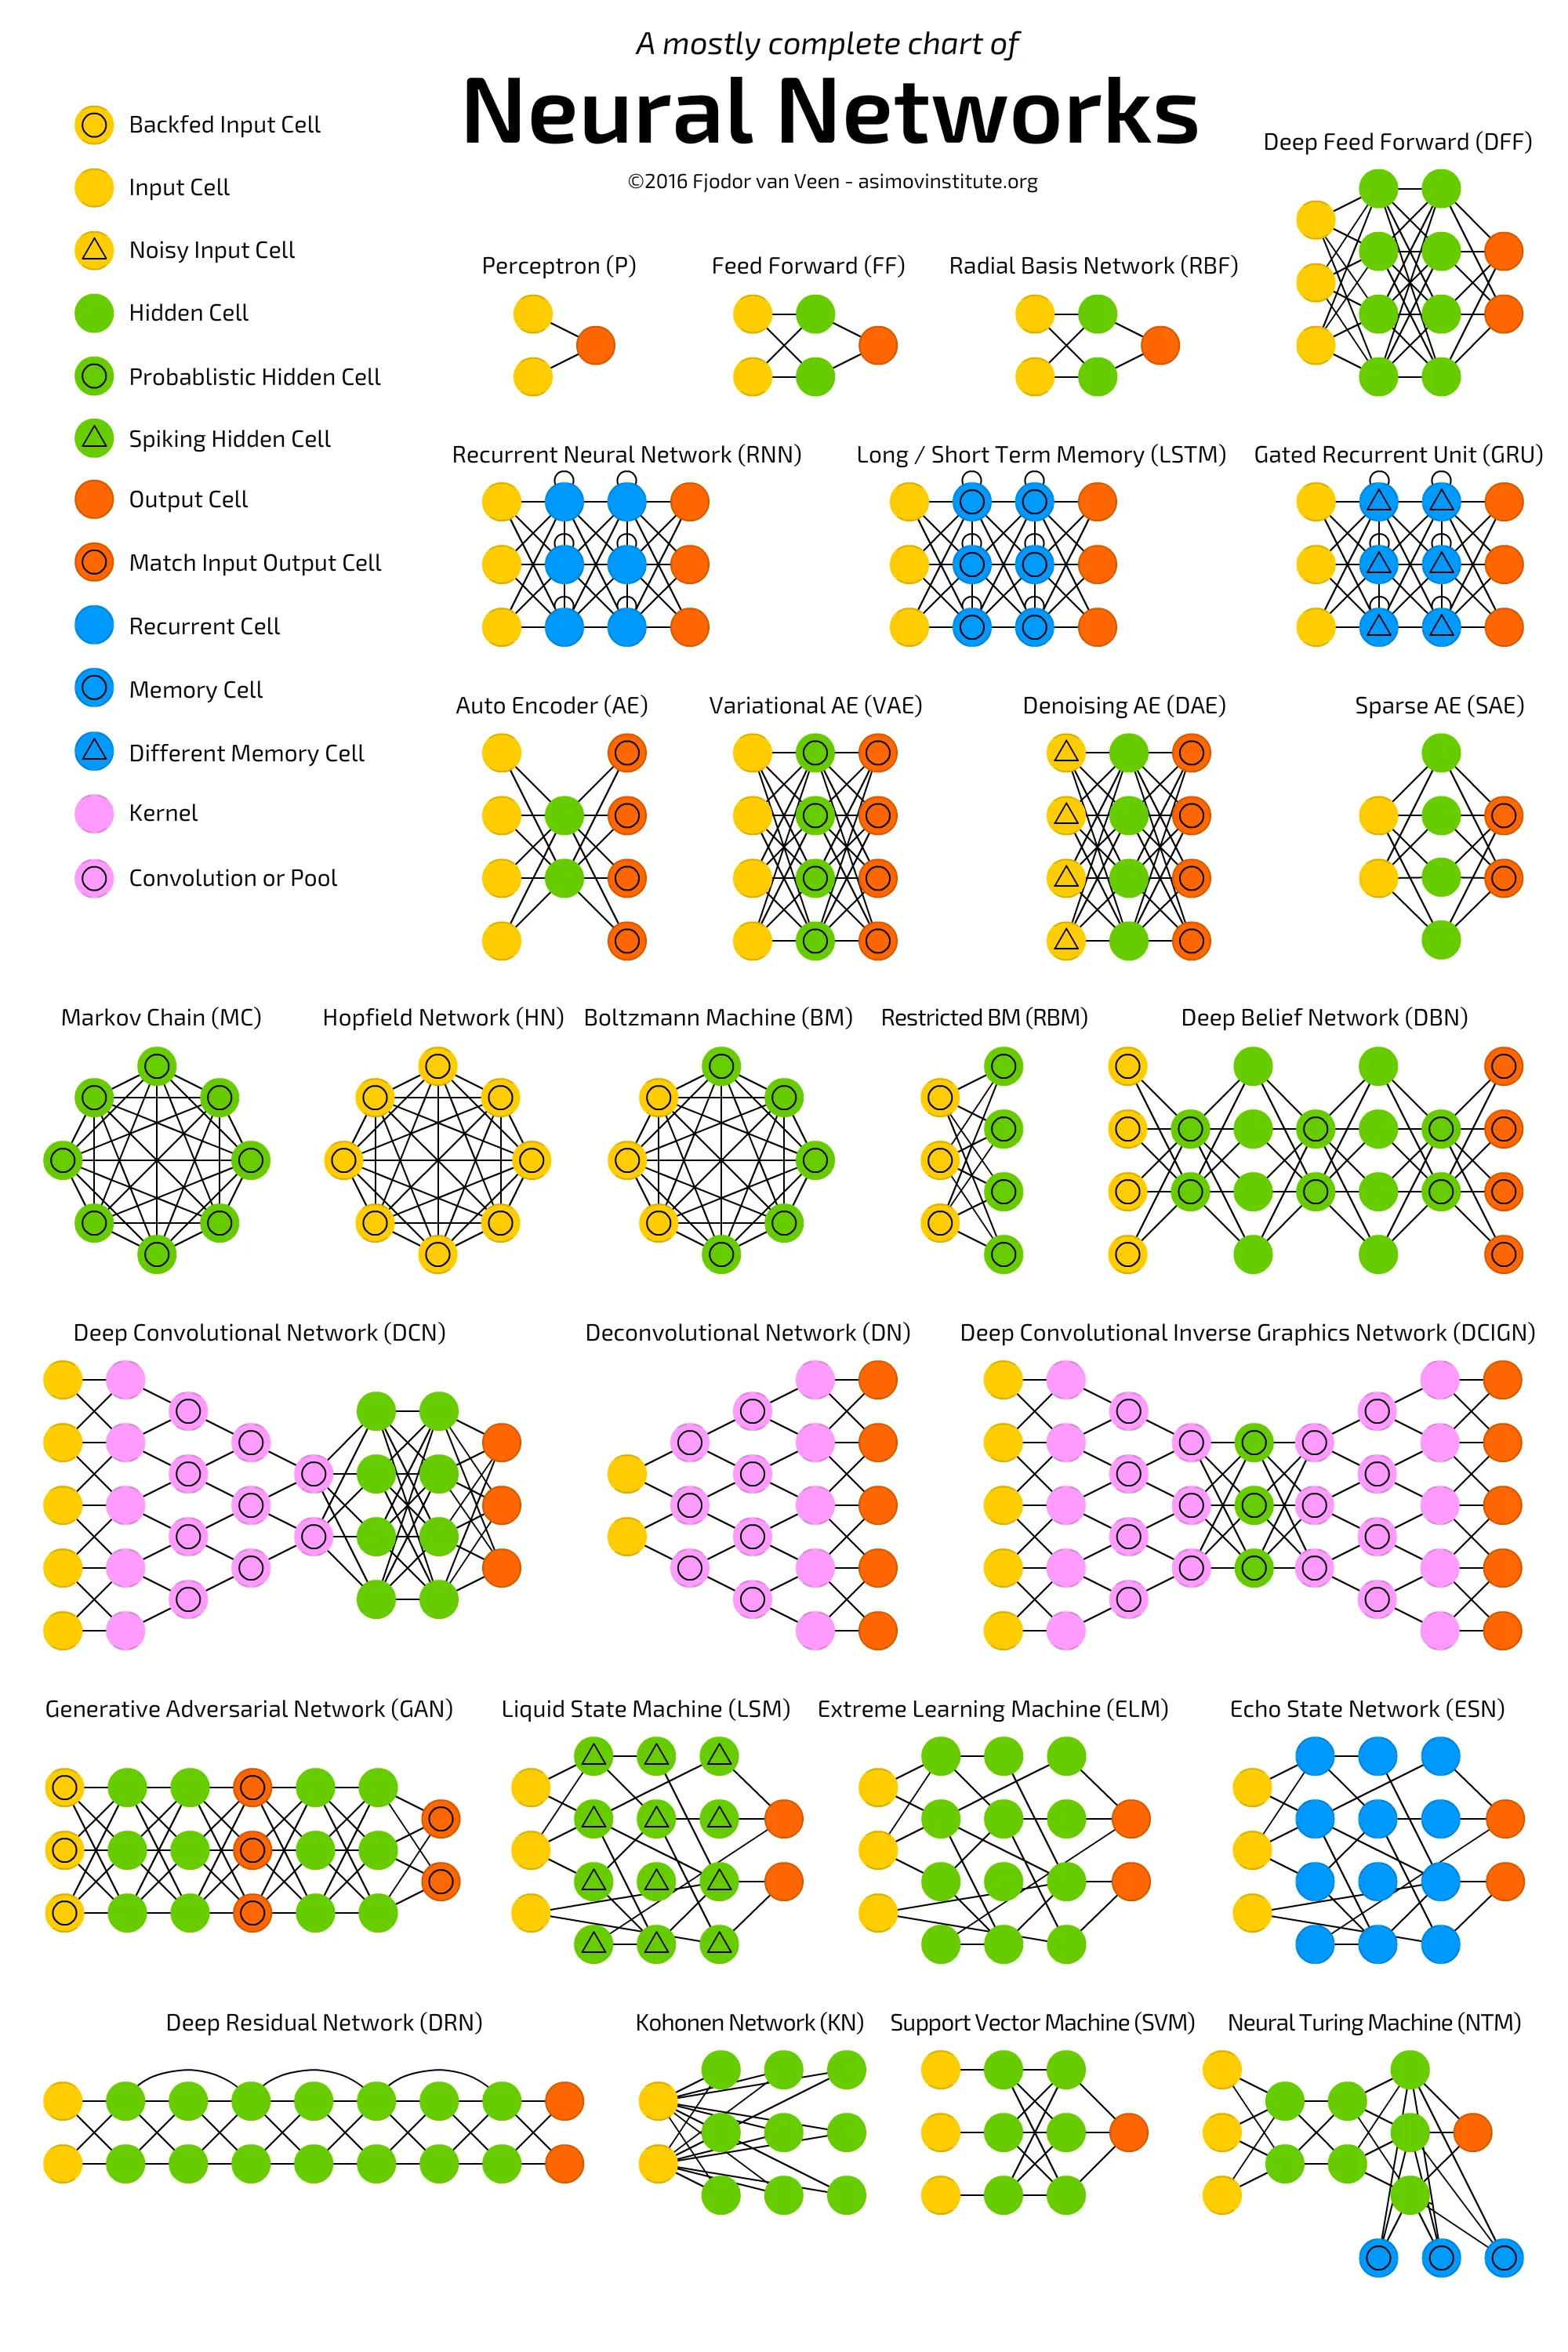

[Источник картинки](https://towardsdatascience.com/the-mostly-complete-chart-of-neural-networks-explained-3fb6f2367464)

В последующих заданиях можно использовать предоставленные датасеты ЛИБО найти какой-либо свой, обладающий схожими характеристиками.

### CNN (4 балла)

Свёрточные нейронные сети работают по принципу "возьмем фильтры с настраиваемыми весами и будем изменять эти веса так, чтобы фильтры выделяли те признаки, которые помогут нам решить задачу". Обычно свёрточные нейронные сети состоят из блоков свёртки и пулинга (уменьшение размерности), поверх которых добавляются несколько полносвязных линейных слоёв. [Визуализация работы свёрточной нейронной сети](https://poloclub.github.io/cnn-explainer/)

Будем решать задачу многоклассовой классификации. Датасет возьмем [отсюда](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data). Он содержит картинки с различными пейзажами. Присутсвуют такие классы, как 'buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'.

Скачайте датасет (можно использвоать библиотеку `opendatasets`)

In [ ]:
import opendatasets as od
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import os

# Скачиваем датасет Intel Image Classification с Kaggle
od.download("https://www.kaggle.com/datasets/puneet6060/intel-image-classification")
print("Датасет скачан")


Создайте даталоадеры для тренировочных и тестовых данных. Используйте `torchvision.datasets.ImageFolder`. Одним из параметров данной функции является `transform`. Попробуйте применить к вашим данным какие-либо [трансформации](https://pytorch.org/vision/stable/transforms.html).

In [ ]:
train_path = "intel-image-classification/seg_train/seg_train"
test_path  = "intel-image-classification/seg_test/seg_test"
batch_size = 256

# Трансформации для train: аугментации + нормализация к [-1, 1]
transformer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),          # случайное горизонтальное отражение
    transforms.RandomRotation(10),              # случайный поворот до 10°
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2),       # вариации яркости и контраста
    transforms.ToTensor(),                      # конвертация PIL -> тензор [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),  # нормализация к [-1, 1]
])

# Трансформации для test: только ресайз и нормализация (без аугментаций)
test_transformer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ImageFolder автоматически считывает классы из названий подпапок
train_dataset_cnn = torchvision.datasets.ImageFolder(root=train_path, transform=transformer)
test_dataset_cnn  = torchvision.datasets.ImageFolder(root=test_path,  transform=test_transformer)

train_loader = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset_cnn,  batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_loader.dataset.classes
print(f"Классы: {class_names}")
print(f"Train: {len(train_dataset_cnn)} изображений")
print(f"Test:  {len(test_dataset_cnn)} изображений")


Выведем пару картинок, обратившись к содержимому даталоадеров.

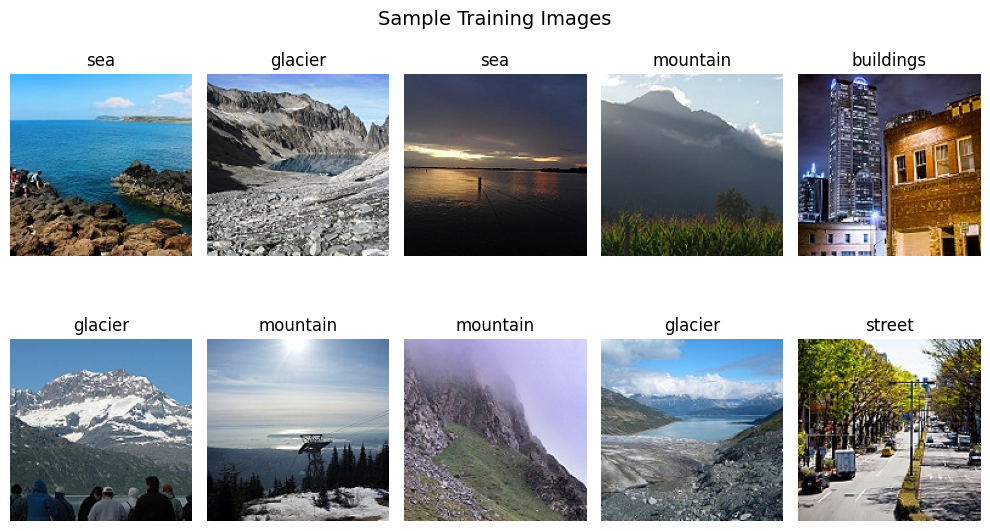

In [ ]:
images, labels = next(iter(train_loader))
class_names = train_loader.dataset.classes

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))
idx = 0

for i in range(2):
    for j in range(5):
        label = class_names[labels[idx].item()]
        ax[i, j].set_title(f"{label}")
        img = images[idx]

        img = img / 2 + 0.5  # обратное преобразование из-за трансформаций. возможно, вам оно не пригодится

        npimg = np.transpose(img.numpy(), (1, 2, 0))
        ax[i, j].imshow(npimg)
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=14)
plt.show()

Реализуйте свёрточную нейронную сеть и обучите её, используя тот же пайплайн, что и в предыдущем задании.

Задача не из простых, так как при использовании свёрточных нейронных сетей нужно внимательно следить за размерностями входных и выходных слоёв. Вам пригодятся такие слои, как Conv2d, BatchNorm2d, MaxPool2d, Linear или любые другие на ваше усмотрение. В качестве функции активации можно использовать ReLU.

Задача достаточно творческая, сфокусируйтесь на проведении экспериментов, а не на том, чтобы "выбить метрику". В данной задаче accuracy выше 0.7 на тесте будем считать хорошим результатом.

In [ ]:
class ConvNet(nn.Module):
    def __init__(self, num_classes=6):
        super(ConvNet, self).__init__()
        # Блок 1: 3->32 фильтра, 64x64 -> 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # Блок 2: 32->64 фильтра, 32x32 -> 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # Блок 3: 64->128 фильтров, 16x16 -> 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # Классификатор: выравниваем карты признаков -> полносвязные слои
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),  # 6 классов пейзажей
        )

    def forward(self, input):
        x = self.block1(input)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


In [ ]:
# Инициализируем модель, функцию потерь и оптимизатор для CNN
cnn_model     = ConvNet(num_classes=6).to(device)
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_scheduler = lr_scheduler.StepLR(cnn_optimizer, step_size=5, gamma=0.5)

num_epochs_cnn   = 10
cnn_train_losses, cnn_test_losses = [], []
cnn_train_accs,   cnn_test_accs   = [], []

for epoch in range(num_epochs_cnn):
    tr_loss, tr_acc = train(
        cnn_model, train_loader, cnn_criterion, cnn_optimizer, cnn_scheduler, device
    )
    te_loss, te_acc = test(cnn_model, test_loader, cnn_criterion, device)

    cnn_train_losses.append(tr_loss)
    cnn_test_losses.append(te_loss)
    cnn_train_accs.append(tr_acc)
    cnn_test_accs.append(te_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs_cnn} | "
        f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | "
        f"Test Loss:  {te_loss:.4f} | Test Acc:  {te_acc:.4f}"
    )

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(cnn_train_losses, label='Train Loss')
ax1.plot(cnn_test_losses,  label='Test Loss')
ax1.set_title('CNN: функция потерь')
ax1.set_xlabel('Эпоха'); ax1.legend()

ax2.plot(cnn_train_accs, label='Train Accuracy')
ax2.plot(cnn_test_accs,  label='Test Accuracy')
ax2.set_title('CNN: точность')
ax2.set_xlabel('Эпоха'); ax2.legend()

plt.tight_layout()
plt.show()

# Псевдоним для использования в следующей ячейке (prediction)
model = cnn_model


Посмотрим, что наша модель предсказывает, на отложенной выборке. Так как для новых данных у нас отсутсвует разметка по классам, придется создать кастомный датасет для подгружения данных по частям. Подгрзить все картинки сразу нельзя - они не поместятся в оперативную память.

Создайте кастомный датасет для того, чтобы картинки подгружались динамически. [Пример можно найти здесь](https://www.learnpytorch.io/04_pytorch_custom_datasets/). Не забудьте применить трансормации, если вы использовали их при обучении модели.

Выведите пример того, что предсказывает ваша модель.

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        # Собираем список всех изображений в папке
        self.images = [
            os.path.join(root_dir, fname)
            for fname in sorted(os.listdir(root_dir))
            if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Динамическая подгрузка: открываем картинку только когда нужна
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


pred_path = "intel-image-classification/seg_pred/seg_pred"
pred_data = CustomDataset(pred_path, transform=transformer)

batch_size = 10
pred_loader = DataLoader(pred_data, batch_size=batch_size, shuffle=False)

model.eval()

images = next(iter(pred_loader)).to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))
idx = 0

for i in range(2):
    for j in range(5):
        label = class_names[predicted[idx].item()]
        ax[i, j].set_title(f"Predicted: {label}")
        img = images[idx].cpu() / 2 + 0.5  # обратное преобразование из-за трансформаций. возможно, вам оно не пригодится
        npimg = np.transpose(img.numpy(), (1, 2, 0))
        ax[i, j].imshow(npimg)
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Prediction Images", fontsize=14)
plt.show()


### RNN (6 баллов)

Recurrent Neural Network или рекуррентная нейронная сеть. Её логическим продолжением стала архитектура LSTM (Long Short-term Memory). Эти архитектуры призваны решать задачу обработки последовательностей и учитывают не только сигналы с непосредственно предыдщуего слоя, но и сигналы с более дальних слоёв.

[Здесь](https://qudata.com/ml/ru/NN_RNN_Torch.html) можно найти хорошее объяснение.

Будем решать задачу генерации текста. Принцип работы следующий: модель имеет представление обо всех словах словаря. На вход модель получает последовательность слов, её задача - определить, какое слово из словаря будет наиболее вероятным продолжением этой последовательности. То есть, по сути решается задача многоклассовой классификации.

В данном случае под "словом" понимает токен - то есть любая единица текстовых данных, которой присвоен код, - будь то буква, слог, слово или несколько слов сразу.

В качестве данных возьмем любую из книг "Игра престолов". Тексты книг можно найти [здесь](https://www.kaggle.com/datasets/khulasasndh/game-of-thrones-books).

Начнем с небольшой предобработки. Напишите функцию предобработки, которая приведет текст к нижнему регистру, удалит из него конструкции вида "Page n". Также удалим все символы, которые не являются буквами, пробелами, точками или вопросительными знаками. В том числе удалим переносы строк.

In [ ]:
import re
import random
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def preprocess_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    # Удаление конструкций "Page N" или "page 123"
    text = re.sub(r'page\s+\d+', '', text)
    # Замена переносов строк пробелом
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Оставляем только буквы, пробелы, точки и вопросительные знаки
    text = re.sub(r"[^a-z .?]", '', text)
    # Убираем лишние пробелы
    text = re.sub(r' +', ' ', text).strip()
    return text


Теперь нам потребуется токенизатор, который будет присваивать словам числовые коды. В качестве метода разбиения текста на составные части предлагается использовать`sent_tokenize` и `word_tokenize` из `nltk`.

In [ ]:
class Tokenizer:
    def __init__(self):
        self.unknown_token = 'UNK'
        self.unknown_index = 0
        self.word2ind = {self.unknown_token: self.unknown_index}
        self.ind2word = {self.unknown_index: self.unknown_token}

    def fit(self, corpus):
        # Заполнение словарей word2ind и ind2word
        # corpus — список предложений (строк)
        idx = 1  # 0 зарезервирован для UNK
        for sentence in corpus:
            for word in word_tokenize(sentence):
                if word not in self.word2ind:
                    self.word2ind[word] = idx
                    self.ind2word[idx] = word
                    idx += 1

    def text2ind(self, text):
        words = word_tokenize(text)
        sequence = [self.word2ind.get(word, self.unknown_index) for word in words]
        return sequence

    def ind2text(self, sequence):
        words = [self.ind2word.get(index, self.unknown_token) for index in sequence]
        return words


Подготовим датасет. Для обучения модели было бы неплохо привести все подаваемые на вход сети последовательности к одной длине. Можно работать и с последовательностями разной длины, если объединять их в батчи, где длины совпадают, но сейчас мы будем придерживаться более простой тактики.

Реализуйте функцию `split_sentences_into_chunks`, которая будет возвращать последовательности длиной `max_seq_length + 1` (единица, так как в дальнейшем крайнее правое слово станет таргетом). Будем добавлять паддинг слева, если длина текста не делится на `max_seq_length + 1` нацело. В качестве значения для паддинга можете использовать `tokenizer.unknown_index`.

In [ ]:
def split_sentences_into_chunks(sentences, tokenizer, max_seq_length=8):
    chunks = []
    pad_token = tokenizer.unknown_index  # UNK используется как токен паддинга
    target_len = max_seq_length + 1      # +1: крайнее правое слово станет таргетом

    for sentence in sentences:
        tokens = tokenizer.text2ind(sentence)

        if len(tokens) < target_len:
            # Предложение короче окна — дополняем паддингом слева
            padded = [pad_token] * (target_len - len(tokens)) + tokens
            chunks.append(padded)
        else:
            # Скользящее окно: из одного длинного предложения получаем много чанков
            for i in range(len(tokens) - max_seq_length):
                chunk = tokens[i : i + target_len]
                chunks.append(chunk)

    return chunks


Теперь создадим класс датасета. Единственная его задача - разделять входную последовательность на то, по чему мы предсказываем, и то, что мы предсказываем. На выходе должны получаться пары вида ([токены], токен).

In [ ]:
class TextDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        chunk = self.data[idx]
        X = chunk[:-1]
        y = chunk[-1]
        return torch.tensor(X), torch.tensor(y)

Сложим всё воедино:

In [ ]:
with open('/content/game-of-thrones-books/001ssb.txt', 'r') as file:  # файл с книгой
    text = file.read()

preprocessed_text = preprocess_text(text)

sentences = sent_tokenize(preprocessed_text)
tokenizer = Tokenizer()
tokenizer.fit(sentences)

data = split_sentences_into_chunks(sentences, tokenizer, max_seq_length=10)
random.shuffle(data)

split_ratio = 0.9  # кастомное разбиение на train-test
train_data = data[:int(split_ratio * len(data))]
test_data = data[int(split_ratio * len(data)):]

train_dataset = TextDataset(train_data)
test_dataset = TextDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

for X_batch, y_batch in train_loader:
    print("X_batch shape:", X_batch.shape)
    print("y_batch shape:", y_batch.shape)
    break

X_batch shape: torch.Size([32, 10])
y_batch shape: torch.Size([32])


Создайте нейронную сеть минимум из следующих слоев: `Embedding`, `LSTM`, `Dropout`, `Linear`.

In [ ]:
class TextGenModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256):
        super(TextGenModel, self).__init__()
        # Embedding: каждый токен -> плотный вектор размера embedding_dim
        # padding_idx=0 — нулевые эмбеддинги для UNK/паддинга
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # LSTM: обрабатывает последовательность, хранит «память»
        # num_layers=2 — два стека LSTM-ячеек
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            batch_first=True, num_layers=2
        )
        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.3)
        # Линейный слой: из скрытого состояния -> логиты по словарю
        self.linear = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded  = self.dropout(self.embedding(x))   # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded)             # (batch, seq_len, hidden_dim)
        # Берём только выход последнего временного шага
        last_out  = self.dropout(lstm_out[:, -1, :])  # (batch, hidden_dim)
        logits    = self.linear(last_out)              # (batch, vocab_size)
        return logits


Обучите модель. Можно использовать тот же пайплайн, что и в предыдущих заданиях.

Нужно отметить, что Accuracy не очень подходит в качестве метрики для задач генерации текста, так как явялется очень грубым приближением качества. Будем ориентироваться не на значение метрики, а на динамику.

Если ваша модель при инференсе не выдает `unk` бесконечно, значит вы всё сделали правильно.

In [ ]:
vocab_size = len(tokenizer.word2ind)
print(f"Размер словаря: {vocab_size}")

rnn_model     = TextGenModel(vocab_size=vocab_size, embedding_dim=128, hidden_dim=256).to(device)
rnn_criterion = nn.CrossEntropyLoss()
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)
rnn_scheduler = lr_scheduler.StepLR(rnn_optimizer, step_size=5, gamma=0.5)

num_epochs_rnn   = 15
rnn_train_losses, rnn_test_losses = [], []
rnn_train_accs,   rnn_test_accs   = [], []

for epoch in range(num_epochs_rnn):
    tr_loss, tr_acc = train(
        rnn_model, train_loader, rnn_criterion, rnn_optimizer, rnn_scheduler, device
    )
    te_loss, te_acc = test(rnn_model, test_loader, rnn_criterion, device)

    rnn_train_losses.append(tr_loss)
    rnn_test_losses.append(te_loss)
    rnn_train_accs.append(tr_acc)
    rnn_test_accs.append(te_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs_rnn} | "
        f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | "
        f"Test Loss:  {te_loss:.4f} | Test Acc:  {te_acc:.4f}"
    )

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(rnn_train_losses, label='Train Loss')
ax1.plot(rnn_test_losses,  label='Test Loss')
ax1.set_title('RNN/LSTM: функция потерь')
ax1.set_xlabel('Эпоха'); ax1.legend()

ax2.plot(rnn_train_accs, label='Train Accuracy')
ax2.plot(rnn_test_accs,  label='Test Accuracy')
ax2.set_title('RNN/LSTM: точность (Accuracy — грубая метрика для генерации)')
ax2.set_xlabel('Эпоха'); ax2.legend()

plt.tight_layout()
plt.show()

# Псевдоним: следующие ячейки с generate_text используют переменную model
model = rnn_model


Попробуйте сгенерировать вашей моделью какой-либо текст. Похоже на слог "Игры престолов"?

In [ ]:
def generate_text(seed_text, tokenizer, model, max_seq_length=8, max_len=120, device='cpu', stops=['.']):
    stops = [tokenizer.word2ind.get(stop) for stop in stops]  # если мы встретили какой-либо из данных символов, то прекращаем генерацию

    model.eval()
    with torch.no_grad():
        seed_tokens = tokenizer.text2ind(seed_text)  # токенизируем текст
        current_tokens = seed_tokens[:]

        if len(current_tokens) < max_seq_length:  # добавим паддинг, если текст слишком короткий
            current_tokens = [tokenizer.unknown_index] * (max_seq_length - len(current_tokens)) + current_tokens

        while len(current_tokens) < max_len:
            inputs = torch.tensor(current_tokens[-max_seq_length:]).unsqueeze(0).to(device)

            outputs = model(inputs)  # предсказания модели
            _, predicted = torch.max(outputs, 1)  # возьмем самый вероятный токен. можно брать случайный из какого-то топа, чтобы добавить случайность
            current_tokens.append(predicted.item())

            if current_tokens[-1] in stops:
                break

    return tokenizer.ind2text(current_tokens)  # преобразование из токенов обратно в слова. можно добавить пост-обработку

In [ ]:
print(generate_text_advanced("winter is", tokenizer, model, max_len=120, device=device, temperature=1.2, top_k=20))

In [ ]:
print(generate_text_advanced("you", tokenizer, model, max_len=120, device=device, temperature=1.2, top_k=20))

In [ ]:
print(generate_text_advanced("i am", tokenizer, model, max_len=120, device=device, temperature=1.2, top_k=20))

In [ ]:
print(generate_text_advanced("when the", tokenizer, model, max_len=120, device=device, temperature=1.2, top_k=20))

In [ ]:
print(generate_text_advanced("it was a", tokenizer, model, max_len=120, device=device, temperature=1.2, top_k=20))

#### Задание 1. Улучшенная генерация текста (Temperature + Top-k sampling)

В базовой версии лабораторной работы генерация следующего слова выполняется жадным способом: модель выбирает токен с максимальной вероятностью (`argmax`).

Такой подход часто приводит к однообразному и повторяющемуся тексту.

Чтобы сделать генерацию более естественной и разнообразной, реализуйте **семплирование** следующего токена на основе распределения вероятностей.

##### Требуется:

1. Добавить поддержку **temperature sampling**:

$$
p = softmax(logits / T)
$$

Где параметр `T` управляет "уверенностью" модели:

- `T < 1` делает генерацию более детерминированной
- `T > 1` увеличивает разнообразие, но может ухудшать связность текста
2. Реализовать **top-k sampling**:

Перед выбором следующего токена оставьте только `k` наиболее вероятных слов, а остальные обнулите.

##### Эксперимент:

Сгенерируйте текст при разных параметрах:

- Temperature: `0.7`, `1.0`, `1.3`
- Top-k: `5`, `20`, `50`

Сравните результаты и сделайте вывод, как параметры влияют на качество и разнообразие текста.

In [ ]:
import torch.nn.functional as F

def generate_text_advanced(
    seed_text, tokenizer, model,
    max_seq_length=10, max_len=120,
    device='cpu', stops=[],
    temperature=1.0, top_k=0
):
    """
    Генерация текста с temperature sampling и top-k фильтрацией.

    temperature < 1 — более детерминированная генерация (модель «уверена»).
    temperature > 1 — больше разнообразия, но хуже связность.
    top_k = 0       — отключён; top_k > 0 — оставляем только k лучших токенов.
    """
    stop_ids = [tokenizer.word2ind.get(s) for s in stops]
    # Токены, которые никогда не выбираем во время генерации
    mask_ids = [tokenizer.unknown_index]
    dot_id = tokenizer.word2ind.get('.')
    if dot_id is not None:
        mask_ids.append(dot_id)

    model.eval()
    with torch.no_grad():
        tokens = tokenizer.text2ind(seed_text)

        # Паддинг, если начальная последовательность слишком короткая
        if len(tokens) < max_seq_length:
            tokens = [tokenizer.unknown_index] * (max_seq_length - len(tokens)) + tokens

        generated = []  # только новые токены (без паддинга и seed)
        while len(generated) < max_len:
            inp = torch.tensor(tokens[-max_seq_length:]).unsqueeze(0).to(device)
            logits = model(inp)  # (1, vocab_size)

            # Маскируем UNK и точку — модель не должна их генерировать
            for mid in mask_ids:
                logits[:, mid] = float('-inf')

            # Temperature sampling
            logits = logits / temperature

            # Top-k фильтрация
            if top_k > 0:
                top_k_vals, _ = torch.topk(logits, top_k, dim=-1)
                threshold = top_k_vals[:, -1].unsqueeze(-1)
                logits = logits.masked_fill(logits < threshold, float('-inf'))

            # Семплируем следующий токен из распределения вероятностей
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

            tokens.append(next_token)
            generated.append(next_token)

            if next_token in stop_ids:
                break

    return ' '.join(tokenizer.ind2text(generated))


# Эксперимент: сравниваем разные комбинации параметров
print("=== Temperature=0.7, Top-k=5 (детерминированная, узкий выбор) ===")
print(generate_text_advanced("winter is", tokenizer, model,
                              device=device, temperature=0.7, top_k=5))

print("\n=== Temperature=1.0, Top-k=20 (нейтральная) ===")
print(generate_text_advanced("winter is", tokenizer, model,
                              device=device, temperature=1.0, top_k=20))

print("\n=== Temperature=1.3, Top-k=50 (разнообразная, менее связная) ===")
print(generate_text_advanced("winter is", tokenizer, model,
                              device=device, temperature=1.3, top_k=50))

print("""
Вывод:
- Temperature=0.7, Top-k=5:  текст повторяется, предсказуем, но грамматически
  более корректный — модель всегда выбирает «самое безопасное» следующее слово.
- Temperature=1.0, Top-k=20: баланс между связностью и разнообразием.
- Temperature=1.3, Top-k=50: наибольшее разнообразие, но текст теряет
  логичность — слова реже образуют осмысленные фразы.
""")


#### Задание 2. Masked Language Modeling (задача восстановления пропусков)

В качестве дополнительного задания можно реализовать альтернативный подход к обучению языковых моделей — **Masked Language Modeling**, как в архитектуре BERT.

Вместо предсказания следующего слова модель должна восстанавливать случайно замаскированные слова внутри последовательности.

Пример:
```
the king <MASK> in the north .
```
Модель должна предсказать: `is`

##### Требуется:

1. Добавить специальный токен `<MASK>`
2. В датасете случайно заменять часть слов на `<MASK>`
3. Обучить модель восстанавливать исходные слова на замаскированных позициях

Если интересно, можно изучить и попробовать повторить [туториал про работу LLM](https://levelup.gitconnected.com/building-a-million-parameter-llm-from-scratch-using-python-f612398f06c2). Кажется, что результаты той модели должны быть лучше, нежели однослойной LSTM-ки :)

### Что еще?

Лабораторная работа получилось достаточно объемной, поэтому мы не будем рассматривать в ней перенос обучения и fine-tuning. Однако при желании вы можете изучить материалы самостоятельно. [Про разницу transfer learning-а и fine-tuning-а](https://dev.to/luxacademy/understanding-the-differences-fine-tuning-vs-transfer-learning-370).

Основная идея переноса обучения заключается в том, что кто-то уже обучил сложную и тяжелую нейронную сеть за нас, а мы теперь используем признаки, которые эта сеть умеет находить, для решения нашей задачи, надстраивая над ней небольшую "шапку", которую мы и обучаем.

Fine-tuning очень похож на перенос обучения, но помимо обучения "шапки" мы так же размораживаем для обучения часть весов модели.

[Хороший пример дообучения BERT-а для задачи анализа тональности](https://github.com/curiousily/Getting-Things-Done-with-Pytorch/blob/master/08.sentiment-analysis-with-bert.ipynb).